# Forecase sale value with LSTM

## Load module

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## Set parameter

In [10]:
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, usecols=['Sales'])
n_train = int(len(df) * 0.8)
n_train

86

In [7]:
df.head()

,Sales
0,6550
1,8728
2,12026
3,14395
4,14587


In [8]:
df.isnull().sum()

Sales    0
dtype: int64

In [9]:
df.shape

(108, 1)

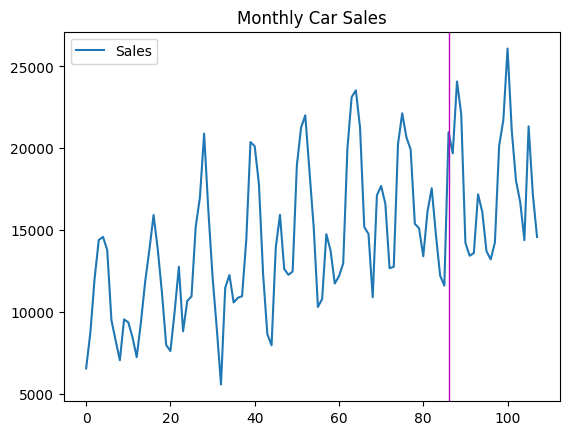

In [13]:
df.plot()
plt.axvline(n_train, c='m', lw=1.0)
plt.title('Monthly Car Sales')
plt.show()

## Prepare data

### Define nomalizer

In [15]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()

### Nomalize

In [17]:
data_sc = sc.fit_transform(df.values)
data_sc[:5]

array([[0.04783011],
       [0.15391359],
       [0.31454873],
       [0.42993522],
       [0.43928693]])

### Convert function for traning

In [18]:
def convertToMatrix(data, step=1):
    X, y = [], []
    for i in range(len(data) - step):
        X.append(data[i:i + step])
        y.append(data[i + step])
    return np.array(X), np.array(y)

In [19]:
train, test = data_sc[:n_train], data_sc[n_train:]
print(f'train shape: {train.shape}, test shape: {test.shape}')

train shape: (86, 1), test shape: (22, 1)


In [24]:
step = 1
X_train, y_train = convertToMatrix(train, step)
X_test, y_test = convertToMatrix(test, step)
# 3D shape: # (samples, time steps, features)
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')
print(f'X_train[:5]:\n{X_train[:5]}')
print(f'y_train[:5]:\n{y_train[:5]}')

X_train shape: (85, 1, 1), y_train shape: (85, 1)
X_test shape: (21, 1, 1), y_test shape: (21, 1)
X_train[:5]:
[[[0.04783011]]

 [[0.15391359]]

 [[0.31454873]]

 [[0.42993522]]

 [[0.43928693]]]
y_train[:5]:
[[0.15391359]
 [0.31454873]
 [0.42993522]
 [0.43928693]
 [0.40051629]]


## Create model

In [39]:
model = Sequential()
# X_train.shape is (samples, time steps, features)
# LSTM parameters: 4 x (hidden units + features + 1) x hidden units
model.add(LSTM(units=32, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 32)                4352      
                                                                 
 dense_4 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4,385
Trainable params: 4,385
Non-trainable params: 0
_________________________________________________________________


## Train model

In [40]:
# es = EarlyStopping(monitor='val_loss', verbose=1, patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=4, verbose=1)

Epoch 1/100
22/22 [==============================] - 1s 5ms/step - loss: 0.1641
Epoch 2/100
22/22 [==============================] - 0s 5ms/step - loss: 0.1277
Epoch 3/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0961
Epoch 4/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0695
Epoch 5/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0481
Epoch 6/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0356
Epoch 7/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0286
Epoch 8/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0262
Epoch 9/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0249
Epoch 10/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0244
Epoch 11/100
22/22 [==============================] - 0s 3ms/step - loss: 0.0241
Epoch 12/100
22/22 [==============================] - 0s 4ms/step - loss: 0.0238
Epoch 13/100
22/22 [=================

## Visualize loss

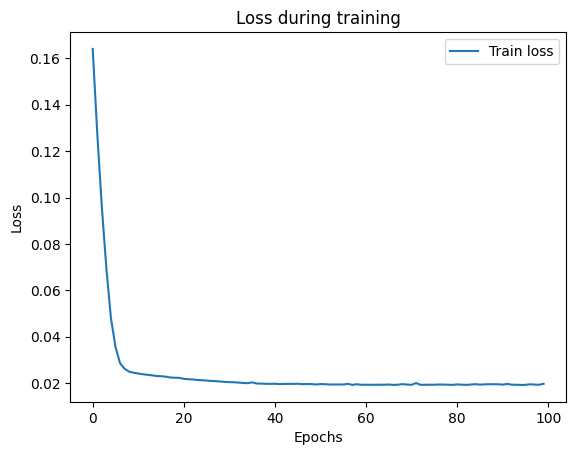

In [41]:
plt.plot(history.history['loss'], label='Train loss')
plt.legend()
plt.title('Loss during training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Evaluate model

In [42]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {score:.4f}')

Test loss: 0.0274


## Consider Train and Test

In [43]:
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
trainPredict_inv = sc.inverse_transform(trainPredict)
testPredict_inv = sc.inverse_transform(testPredict)
y_train_inv = sc.inverse_transform(y_train)
y_test_inv = sc.inverse_transform(y_test)

r2_train = r2_score(y_train_inv, trainPredict_inv)
r2_test = r2_score(y_test_inv, testPredict_inv)

rmse_train = np.sqrt(mean_squared_error(y_train_inv, trainPredict_inv))
rmse_test = np.sqrt(mean_squared_error(y_test_inv, testPredict_inv))

print(f'Train R^2: {r2_train:.4f}, RMSE: {rmse_train:.4f}')
print(f'Test R^2: {r2_test:.4f}, RMSE: {rmse_test:.4f}')

1/1 [==============================] - 0s 12ms/step
Train R^2: 0.5490, RMSE: 2844.3852
Test R^2: 0.1949, RMSE: 3399.4621


## Ploting result

In [45]:
prefix = np.empty(step).reshape(-1,1)
prefix.fill(np.nan)

trainPredict_plot = np.concatenate((prefix, trainPredict_inv), axis=0)
testPredict_plot = np.concatenate((prefix, testPredict_inv), axis=0)

predicted_inv = np.concatenate((trainPredict_plot, testPredict_plot), axis=0)

None


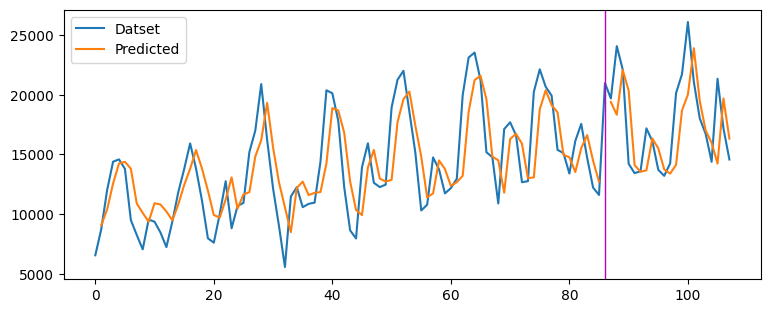

In [46]:
plt.figure(figsize=(9, 3.5))
plt.plot(df.values, label='Datset')
plt.plot(predicted_inv, label='Predicted')
plt.axvline(n_train, c='m', lw=1.0)
plt.legend()
plt.show()